# Cats and Dogs CNN: Manual Hyperparameters vs. Keras Tuner
Run the cells in order on Google Colab with a GPU or in your TensorFlow environment. This notebook rebuilds the manual CNN from `Loading_Dataset_and_CNN_(2).ipynb`, compares three hand-selected configurations with Keras Tuner RandomSearch, and generates a Word report containing actual results.

**Execution status:** new experiments have not been run in this supplied notebook. Historical results below are copied from the earlier executed notebook, not from the new experiments. Save the notebook with outputs after Run All.

The earlier manual form had blank chosen-value fields; settings here come from the executed code. Both Dense(64) layers in that code had **linear** activation. This is preserved for the original baseline.


## 1. Install dependencies
Uncomment the installation line if needed. Restart the kernel if installing TensorFlow into an active session.


In [1]:
# %pip install tensorflow keras-tuner opencv-python-headless numpy pandas matplotlib scikit-learn python-docx
import os, sys, json, time, hashlib, platform, importlib.metadata
from pathlib import Path
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
import keras_tuner as kt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
from IPython.display import display
SEED = 42
keras.utils.set_random_seed(SEED)
for gpu in tf.config.list_physical_devices('GPU'):
    tf.config.experimental.set_memory_growth(gpu, True)
print('TensorFlow:', tf.__version__, 'Keras Tuner:', kt.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))


I0000 00:00:1791180047.871236     779 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow: 2.21.0 Keras Tuner: 1.4.8
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Dataset and experiment controls
Use the same `PetImages` dataset as the earlier activity: set DATA_DIR to its parent of Dog/ and Cat/. In Colab, mount Drive first if the extracted dataset is there. If DATA_DIR is absent, the notebook downloads TensorFlow's smaller filtered cats-and-dogs dataset. This fallback is clearly identified in the report and cannot reproduce the earlier 24,997-image run.

Every new experiment uses the same stratified 64% training / 16% validation / 20% test split. The test set is excluded from manual selection and tuner search. The 64/16 division retains a 20% validation fraction within the non-test data. Five epochs and batch size 128 match the earlier run. Increase EPOCHS before running the whole experiment if required; keep it equal across methods.


In [2]:
DATA_DIR = Path('/content/PetImages')  # EDIT for your extracted dataset
# Colab + Google Drive alternative (run before selecting DATA_DIR):
# from google.colab import drive
# drive.mount('/content/drive')
DATA_DIR = Path('/mnt/d/DIT/1st Sem/BioInformatics/Activity Sept 9 2026/PetImages')
IMG_SIZE = 128
BATCH_SIZE = 128
EPOCHS = 5
MAX_TRIALS = 8
OUTPUT_DIR = Path('cnn_activity_results')
OUTPUT_DIR.mkdir(exist_ok=True)
if DATA_DIR.is_dir():
    roots = [DATA_DIR]
    DATASET_SOURCE = 'User-supplied PetImages (Dog/Cat folders)'
else:
    url = 'https://storage.googleapis.com/mledu-datasets/cats_and_dogs_filtered.zip'
    archive = keras.utils.get_file('cats_and_dogs_filtered.zip', origin=url, extract=True)
    candidates = [Path(archive).parent / 'cats_and_dogs_filtered',
                  Path(archive).parent / 'cats_and_dogs_filtered_extracted' / 'cats_and_dogs_filtered']
    candidates += list(Path(archive).parent.glob('*/cats_and_dogs_filtered'))
    base = next((p for p in candidates if (p / 'train').is_dir()), None)
    if base is None:
        raise FileNotFoundError('Locate extracted cats_and_dogs_filtered and set DATA_DIR manually.')
    roots = [base / 'train', base / 'validation']
    DATASET_SOURCE = 'TensorFlow cats_and_dogs_filtered; pooled and re-split'
print(DATASET_SOURCE)
print("Dataset exists:", DATA_DIR.is_dir())
print("Dog folder exists:", (DATA_DIR / "Dog").is_dir())
print("Cat folder exists:", (DATA_DIR / "Cat").is_dir())


User-supplied PetImages (Dog/Cat folders)
Dataset exists: True
Dog folder exists: True
Cat folder exists: True


## 3. Validate images and preserve label mapping
Dog = 0, Cat = 1, matching the original notebook. OpenCV converts to grayscale and resizes to 128×128. Invalid images are logged. Exact duplicate file bytes are removed before splitting; conflicting duplicate labels trigger an error. Images stream from disk rather than loading the full float image array into RAM.


In [5]:
from sklearn.model_selection import train_test_split
skipped, duplicates = [], []
seen = {}
conflicting_hashes = set()

for root in roots:
    for names, label in [
        (("Dog", "dog", "dogs"), 0),
        (("Cat", "cat", "cats"), 1)
    ]:
        folder = next(
            (root / name for name in names
             if (root / name).is_dir()),
            None
        )

        if folder is None:
            raise FileNotFoundError(
                f"No class folder for {names} under {root}"
            )

        for path in sorted(folder.rglob("*")):
            if (
                not path.is_file()
                or path.suffix.lower()
                not in {".jpg", ".jpeg", ".png", ".bmp"}
            ):
                continue

            image = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)

            if image is None or image.size == 0:
                skipped.append(str(path))
                continue

            digest = hashlib.sha256(path.read_bytes()).hexdigest()

            if digest in seen:
                duplicates.append(str(path))

                if seen[digest][1] != label:
                    conflicting_hashes.add(digest)

                continue

            seen[digest] = (str(path), label)

# Remove every copy of images with conflicting labels.
records = [
    record
    for digest, record in seen.items()
    if digest not in conflicting_hashes
]

files = pd.DataFrame(records, columns=["path", "label"])

# Reserve 20% for independent testing.
trainval, test = train_test_split(
    files,
    test_size=0.20,
    stratify=files["label"],
    random_state=SEED
)

# Split the remaining data into training and validation.
train, val = train_test_split(
    trainval,
    test_size=0.20,
    stratify=trainval["label"],
    random_state=SEED
)

# Save the exact split used by all models.
for name, frame in [
    ("train", train),
    ("validation", val),
    ("test", test)
]:
    frame.to_csv(
        OUTPUT_DIR / f"{name}_manifest.csv",
        index=False
    )
    print(
        name,
        len(frame),
        frame["label"].value_counts().sort_index().to_dict()
    )

(OUTPUT_DIR / "skipped_images.json").write_text(
    json.dumps(skipped, indent=2)
)

(OUTPUT_DIR / "duplicate_images.json").write_text(
    json.dumps(duplicates, indent=2)
)

print("Conflicting image groups excluded:",
      len(conflicting_hashes))
def read_cv(path):
    image = cv2.imread(path.decode('utf-8'), cv2.IMREAD_GRAYSCALE)
    if image is None:
        raise ValueError(f'Image became unreadable: {path}')
    return cv2.resize(image, (IMG_SIZE,IMG_SIZE)).astype(np.float32)[...,None] / 255.0

def make_ds(frame, training=False):
    ds = tf.data.Dataset.from_tensor_slices((frame.path.to_numpy(), frame.label.to_numpy(dtype=np.float32)))
    if training:
        ds = ds.shuffle(len(frame), seed=SEED, reshuffle_each_iteration=True)
    def load(path, label):
        image = tf.numpy_function(read_cv, [path], tf.float32)
        image.set_shape((IMG_SIZE,IMG_SIZE,1))
        return image, tf.reshape(label, (1,))
    options = tf.data.Options(); options.experimental_deterministic = True
    return ds.map(load, num_parallel_calls=tf.data.AUTOTUNE).batch(BATCH_SIZE).with_options(options).prefetch(tf.data.AUTOTUNE)
val_ds, test_ds = make_ds(val), make_ds(test)


Corrupt JPEG data: 399 extraneous bytes before marker 0xd9
Corrupt JPEG data: 226 extraneous bytes before marker 0xd9
Corrupt JPEG data: 162 extraneous bytes before marker 0xd9
Corrupt JPEG data: 1403 extraneous bytes before marker 0xd9
Corrupt JPEG data: 254 extraneous bytes before marker 0xd9
Corrupt JPEG data: 2230 extraneous bytes before marker 0xd9
Corrupt JPEG data: 65 extraneous bytes before marker 0xd9
Corrupt JPEG data: 239 extraneous bytes before marker 0xd9
Corrupt JPEG data: 214 extraneous bytes before marker 0xd9
Corrupt JPEG data: 128 extraneous bytes before marker 0xd9
Corrupt JPEG data: 99 extraneous bytes before marker 0xd9
Corrupt JPEG data: 1153 extraneous bytes before marker 0xd9


train 15977 {0: 7991, 1: 7986}
validation 3995 {0: 1998, 1: 1997}
test 4993 {0: 2497, 1: 2496}
Conflicting image groups excluded: 2


I0000 00:00:1791181435.635584     779 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6094 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2070 with Max-Q Design, pci bus id: 0000:01:00.0, compute capability: 7.5


## 4. Historical manual evidence
Source: earlier notebook cell 33 (architecture), cell 35 (training), and cell 36 (plots/evaluation). Historical confusion-matrix/ROC predictions included training data, so they are not treated as independent test results. The earlier shuffled split was not seeded; its scores are context only, not a controlled comparison with this new split.


In [6]:
historical = pd.DataFrame({
    'epoch':[1,2,3,4,5], 'training_accuracy':[.6077,.6992,.7471,.7791,.7967],
    'training_loss':[.6570,.5817,.5214,.4725,.4406],
    'validation_accuracy':[.6848,.7240,.7674,.7816,.7762],
    'validation_loss':[.6061,.5587,.4952,.4792,.4952]})
display(historical)
print('Best historical validation accuracy: 78.16% (epoch 4); final: 77.62% (epoch 5).')


,epoch,training_accuracy,training_loss,validation_accuracy,validation_loss
0,1,0.6077,0.6570,0.6848,0.6061
1,2,0.6992,0.5817,0.7240,0.5587
2,3,0.7471,0.5214,0.7674,0.4952
3,4,0.7791,0.4725,0.7816,0.4792
4,5,0.7967,0.4406,0.7762,0.4952


Best historical validation accuracy: 78.16% (epoch 4); final: 77.62% (epoch 5).


## 5. Shared CNN builder and manual choices
Keep three convolution/max-pooling blocks, flattening, two dense layers and sigmoid output. Vary first-layer filters, shared kernel size, dense width/activation, dropout and Adam learning rate. No augmentation or pretrained features are added, keeping the comparison focused on hyperparameters.
Manual choices are proposed configurations; only the original setting has historical outputs. They are trained below and selected using validation loss alone.


In [7]:
def build_cnn(config):
    model = keras.Sequential([keras.layers.Input((IMG_SIZE,IMG_SIZE,1))])
    for filters in [config['filters_1'],64,64]:
        model.add(keras.layers.Conv2D(filters, config['kernel_size'], activation='relu', padding='valid'))
        model.add(keras.layers.MaxPooling2D(2))
    model.add(keras.layers.Flatten())
    for _ in range(2):
        model.add(keras.layers.Dense(config['dense_units'], activation=config['dense_activation']))
    model.add(keras.layers.Dropout(config['dropout']))
    model.add(keras.layers.Dense(1, activation='sigmoid'))
    model.compile(optimizer=keras.optimizers.Adam(config['learning_rate']),
                  loss='binary_crossentropy', metrics=['accuracy'])
    return model
MANUAL_CONFIGS = [
 dict(name='Original manual baseline',filters_1=2,kernel_size=3,dense_units=64,dense_activation='linear',dropout=0.,learning_rate=.001),
 dict(name='Manual wider first layer',filters_1=32,kernel_size=3,dense_units=64,dense_activation='relu',dropout=.25,learning_rate=.001),
 dict(name='Manual slower learning',filters_1=64,kernel_size=3,dense_units=128,dense_activation='relu',dropout=.5,learning_rate=.0001)]
display(pd.DataFrame(MANUAL_CONFIGS))

def fit_configuration(config, name):
    keras.backend.clear_session(); keras.utils.set_random_seed(SEED)
    model = build_cnn(config)
    checkpoint = OUTPUT_DIR / (name + '.keras')
    start = time.perf_counter()
    history = model.fit(make_ds(train,training=True), validation_data=val_ds, epochs=EPOCHS,
        callbacks=[keras.callbacks.ModelCheckpoint(str(checkpoint), monitor='val_loss', save_best_only=True)], verbose=1)
    seconds = time.perf_counter()-start
    pd.DataFrame(history.history).to_csv(OUTPUT_DIR / (name+'_history.csv'),index=False)
    model = keras.models.load_model(checkpoint)
    best_epoch = int(np.argmin(history.history['val_loss']))+1
    return model, history.history, seconds, best_epoch
manual_runs = []
manual_start = time.perf_counter()
for i, config in enumerate(MANUAL_CONFIGS):
    model, history, seconds, epoch = fit_configuration(config, f'manual_{i}')
    manual_runs.append(dict(index=i, name=config['name'], best_epoch=epoch,
        validation_loss=history['val_loss'][epoch-1],
        validation_accuracy=history['val_accuracy'][epoch-1], training_seconds=seconds,
        history=history))
manual_search_seconds = time.perf_counter()-manual_start
manual_table = pd.DataFrame([{k:v for k,v in r.items() if k!='history'} for r in manual_runs])
display(manual_table)
best_manual = min(manual_runs, key=lambda r:r['validation_loss'])
manual_model = keras.models.load_model(OUTPUT_DIR / f"manual_{best_manual['index']}.keras")


,name,filters_1,kernel_size,dense_units,dense_activation,dropout,learning_rate
0,Original manual baseline,2,3,64,linear,0.00,0.0010
1,Manual wider first layer,32,3,64,relu,0.25,0.0010
2,Manual slower learning,64,3,128,relu,0.50,0.0001


Epoch 1/5


/home/mis/tf-gpu/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
I0000 00:00:1791181439.708017    1445 service.cc:153] XLA service 0x7f57b40b47b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1791181439.708059    1445 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 2070 with Max-Q Design, Compute Capability 7.5 (Driver: 13.4.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.25.1)
Corrupt JPEG data: 2230 extraneous bytes before marker 0xd9
I0000 00:00:1791181439.778047    1445 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1791181440.156797    1445 cuda_dnn.cc:461] Loaded cuDNN version 92501

  3/125 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step - accuracy: 0.4766 - loss: 0.8417 

I0000 00:00:1791181444.660073    1445 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


...

Corrupt JPEG data: 1403 extraneous bytes before marker 0xd9


125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step - accuracy: 0.7576 - loss: 0.5023

Corrupt JPEG data: 254 extraneous bytes before marker 0xd9
Corrupt JPEG data: 399 extraneous bytes before marker 0xd9


125/125 ━━━━━━━━━━━━━━━━━━━━ 30s 238ms/step - accuracy: 0.7576 - loss: 0.5023 - val_accuracy: 0.7542 - val_loss: 0.5092


,index,name,best_epoch,validation_loss,validation_accuracy,training_seconds
0,0,Original manual baseline,5,0.459161,0.792240,127.622001
1,1,Manual wider first layer,5,0.416053,0.811014,140.160023
2,2,Manual slower learning,5,0.509197,0.754193,165.637504


## 6. Keras Tuner RandomSearch
Eight trials explore the search space and minimize validation loss. Each candidate has the same five-epoch limit as each manual candidate. Automated search uses more total computation (eight configurations versus three); times are reported separately. Overwrite=True starts a fresh search; use False only to resume this exact unchanged experiment. The best configuration is retrained from scratch with the same seed and epoch budget before evaluation.


In [8]:
def build_model(hp):
    return build_cnn(dict(
        filters_1=hp.Choice('filters_1',[2,16,32,64]),
        kernel_size=hp.Choice('kernel_size',[3,5]),
        dense_units=hp.Choice('dense_units',[64,128]),
        dense_activation=hp.Choice('dense_activation',['linear','relu']),
        dropout=hp.Choice('dropout',[0.,.25,.5]),
        learning_rate=hp.Choice('learning_rate',[.0001,.001])))
keras.backend.clear_session(); keras.utils.set_random_seed(SEED)
tuner = kt.RandomSearch(build_model, objective=kt.Objective('val_loss',direction='min'),
    max_trials=MAX_TRIALS, executions_per_trial=1, seed=SEED, overwrite=True,
    directory=str(OUTPUT_DIR / 'tuner'), project_name='cats_dogs')
tuner.search_space_summary()
start = time.perf_counter()
tuner.search(make_ds(train,training=True), validation_data=val_ds, epochs=EPOCHS, verbose=1)
tuner_search_seconds = time.perf_counter()-start
tuner.results_summary(num_trials=3)
best_hp = tuner.get_best_hyperparameters(1)[0]
print('Selected hyperparameters:',best_hp.values)
trial_rows = [dict(trial_id=t.trial_id, status=t.status, validation_loss=t.score, **t.hyperparameters.values)
              for t in tuner.oracle.trials.values()]
trials_df = pd.DataFrame(trial_rows).sort_values('validation_loss',na_position='last')
trials_df.to_csv(OUTPUT_DIR/'tuner_trials.csv',index=False)
display(trials_df.head(3))
(OUTPUT_DIR/'best_hyperparameters.json').write_text(json.dumps(best_hp.values,indent=2))
tuned_model,tuned_history,tuned_fit_seconds,tuned_epoch = fit_configuration(best_hp.values,'tuned_final')


Trial 8 Complete [00h 02m 36s]
val_loss: 0.49996399879455566

Best val_loss So Far: 0.4434813857078552
Total elapsed time: 00h 17m 46s
Results summary
Results in cnn_activity_results/tuner/cats_dogs
Showing 3 best trials
Objective(name="val_loss", direction="min")

Trial 1 summary
Hyperparameters:
filters_1: 32
kernel_size: 3
dense_units: 64
dense_activation: linear
dropout: 0.5
learning_rate: 0.001
Score: 0.4434813857078552

Trial 5 summary
Hyperparameters:
filters_1: 2
kernel_size: 3
dense_units: 128
dense_activation: linear
dropout: 0.25
learning_rate: 0.001
Score: 0.48129430413246155

Trial 0 summary
Hyperparameters:
filters_1: 32
kernel_size: 3
dense_units: 64
dense_activation: linear
dropout: 0.5
learning_rate: 0.0001
Score: 0.4970424771308899
Selected hyperparameters: {'filters_1': 32, 'kernel_size': 3, 'dense_units': 64, 'dense_activation': 'linear', 'dropout': 0.5, 'learning_rate': 0.001}


,trial_id,status,validation_loss,filters_1,kernel_size,dense_units,dense_activation,dropout,learning_rate
1,1,COMPLETED,0.443481,32,3,64,linear,0.50,0.0010
5,5,COMPLETED,0.481294,2,3,128,linear,0.25,0.0010
0,0,COMPLETED,0.497042,32,3,64,linear,0.50,0.0001


Epoch 1/5


/home/mis/tf-gpu/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
Corrupt JPEG data: 2230 extraneous bytes before marker 0xd9
I0000 00:00:1791182944.893171    1446 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_69578__.37


 32/125 ━━━━━━━━━━━━━━━━━━━━ 13s 142ms/step - accuracy: 0.5103 - loss: 0.7179

...

105/125 ━━━━━━━━━━━━━━━━━━━━ 3s 166ms/step - accuracy: 0.8115 - loss: 0.4143

Corrupt JPEG data: 1403 extraneous bytes before marker 0xd9


125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - accuracy: 0.8105 - loss: 0.4151

Corrupt JPEG data: 254 extraneous bytes before marker 0xd9
Corrupt JPEG data: 399 extraneous bytes before marker 0xd9


125/125 ━━━━━━━━━━━━━━━━━━━━ 28s 223ms/step - accuracy: 0.8105 - loss: 0.4151 - val_accuracy: 0.7905 - val_loss: 0.4612


## 7. Controlled comparison and unseen-test evaluation
Compare the validation-selected checkpoints. Accuracy gain is expressed in percentage points. Precision, recall and F1 are macro averages across Dog and Cat; ROC AUC uses the Cat probability. Never choose or retune a model using the test scores. This is a single-seed comparison, not evidence of statistical significance.


Corrupt JPEG data: 239 extraneous bytes before marker 0xd9
Corrupt JPEG data: 162 extraneous bytes before marker 0xd9
Corrupt JPEG data: 65 extraneous bytes before marker 0xd9
Corrupt JPEG data: 1403 extraneous bytes before marker 0xd9
Corrupt JPEG data: 226 extraneous bytes before marker 0xd9
Corrupt JPEG data: 214 extraneous bytes before marker 0xd9
Corrupt JPEG data: 2230 extraneous bytes before marker 0xd9
Corrupt JPEG data: 99 extraneous bytes before marker 0xd9
Corrupt JPEG data: 254 extraneous bytes before marker 0xd9
Corrupt JPEG data: 399 extraneous bytes before marker 0xd9
Corrupt JPEG data: 128 extraneous bytes before marker 0xd9
Corrupt JPEG data: 1153 extraneous bytes before marker 0xd9
Corrupt JPEG data: 128 extraneous bytes before marker 0xd9
Corrupt JPEG data: 1153 extraneous bytes before marker 0xd9
Corrupt JPEG data: 239 extraneous bytes before marker 0xd9
Corrupt JPEG data: 162 extraneous bytes before marker 0xd9
Corrupt JPEG data: 65 extraneous bytes before marker 0

,best_epoch,parameters,training_accuracy,training_loss,validation_accuracy,validation_loss,test_accuracy,test_loss,macro_precision,macro_recall,macro_f1,roc_auc
method,,,,,,,,,,,,
Manual selected,5,862849,0.867372,0.310072,0.811014,0.416053,0.823353,0.397397,0.823356,0.823352,0.823352,0.902045
Keras Tuner selected,5,862849,0.824247,0.386739,0.790488,0.461194,0.788904,0.456093,0.798425,0.788922,0.787214,0.880511


Keras Tuner changed validation accuracy by -2.05 percentage points and validation loss by +0.0451 relative to the selected manual CNN. The unseen-test accuracy difference was -3.44 percentage points. The direction and magnitude come from this run; automated tuning does not guarantee improvement. The search covers eight configurations versus three manual configurations, so total search budgets differ.


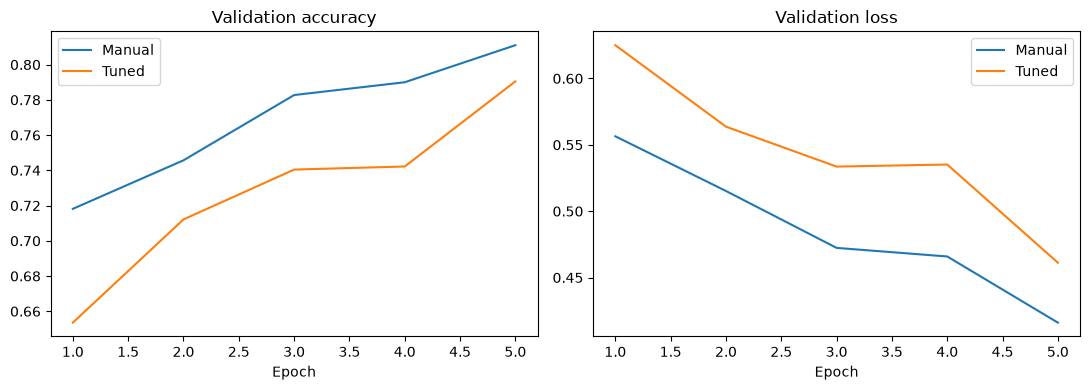

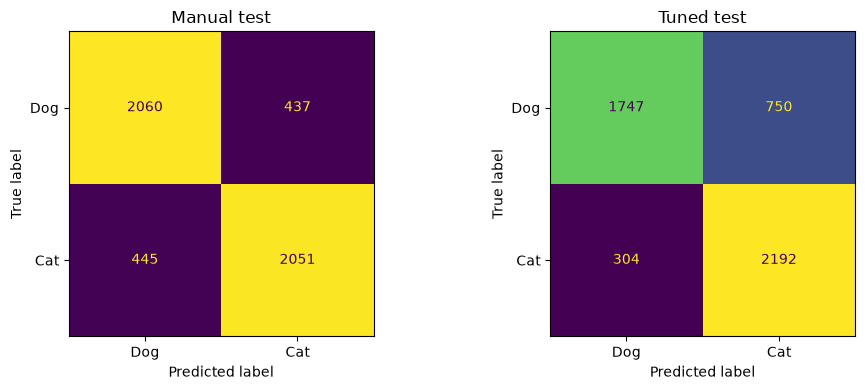

In [9]:
def evaluate_selected(model,name,history,epoch):
    train_eval = model.evaluate(make_ds(train),verbose=0,return_dict=True)
    val_eval = model.evaluate(val_ds,verbose=0,return_dict=True)
    test_eval = model.evaluate(test_ds,verbose=0,return_dict=True)
    probs = model.predict(test_ds,verbose=0).ravel()
    truth = test.label.to_numpy(); pred = (probs>=.5).astype(int)
    precision,recall,f1,_ = precision_recall_fscore_support(truth,pred,average='macro',zero_division=0)
    return dict(method=name,best_epoch=epoch,parameters=model.count_params(),
        training_accuracy=train_eval['accuracy'],training_loss=train_eval['loss'],
        validation_accuracy=val_eval['accuracy'],validation_loss=val_eval['loss'],
        test_accuracy=accuracy_score(truth,pred),test_loss=test_eval['loss'],
        macro_precision=precision,macro_recall=recall,macro_f1=f1,roc_auc=roc_auc_score(truth,probs)), confusion_matrix(truth,pred)
manual_row,manual_cm = evaluate_selected(manual_model,'Manual selected',best_manual['history'],best_manual['best_epoch'])
tuned_row,tuned_cm = evaluate_selected(tuned_model,'Keras Tuner selected',tuned_history,tuned_epoch)
comparison = pd.DataFrame([manual_row,tuned_row]).set_index('method')
comparison.to_csv(OUTPUT_DIR/'comparison.csv')
display(comparison)
val_gain = 100*(tuned_row['validation_accuracy']-manual_row['validation_accuracy'])
test_gain = 100*(tuned_row['test_accuracy']-manual_row['test_accuracy'])
loss_change = tuned_row['validation_loss']-manual_row['validation_loss']
conclusion = (f'Keras Tuner changed validation accuracy by {val_gain:+.2f} percentage points '
    f'and validation loss by {loss_change:+.4f} relative to the selected manual CNN. '
    f'The unseen-test accuracy difference was {test_gain:+.2f} percentage points. '
    'The direction and magnitude come from this run; automated tuning does not guarantee improvement. '
    'The search covers eight configurations versus three manual configurations, so total search budgets differ.')
print(conclusion)
fig,axes=plt.subplots(1,2,figsize=(11,4))
for label,h in [('Manual',best_manual['history']),('Tuned',tuned_history)]:
    axes[0].plot(range(1,len(h['val_accuracy'])+1),h['val_accuracy'],label=label)
    axes[1].plot(range(1,len(h['val_loss'])+1),h['val_loss'],label=label)
for ax,title in zip(axes,['Validation accuracy','Validation loss']):
    ax.set_title(title); ax.set_xlabel('Epoch'); ax.legend()
fig.tight_layout();fig.savefig(OUTPUT_DIR/'learning_curves.png',dpi=180);plt.show()
fig,axes=plt.subplots(1,2,figsize=(10,4))
for ax,cm,title in zip(axes,[manual_cm,tuned_cm],['Manual test','Tuned test']):
    ConfusionMatrixDisplay(cm,display_labels=['Dog','Cat']).plot(ax=ax,colorbar=False)
    ax.set_title(title)
fig.tight_layout();fig.savefig(OUTPUT_DIR/'test_confusion_matrices.png',dpi=180);plt.show()


## 8. Generate the final Word report and save the environment
The .docx report below is populated from measured variables in this run. Open it in Word and check its tables and plots before submission. The notebook itself must be saved after execution to preserve outputs. `.docx` is the standard Word extension (rather than `.docs`).


In [11]:
#%pip install python-docx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 1.7 MB/s eta 0:00:00a 0:00:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 13.0 MB/s eta 0:00:0000:0100:01
Note: you may need to restart the kernel to use updated packages.


In [12]:
def report_document(path, comparison=None, conclusion=None):
    from docx import Document
    from docx.shared import Inches, Pt, RGBColor
    doc=Document()
    from docx.oxml.ns import qn
    for style in doc.styles:
        for border in list(style.element.iter(qn('w:pBdr'))):
            border.getparent().remove(border)
    sec=doc.sections[0]; sec.top_margin=sec.bottom_margin=Inches(.7)
    sec.left_margin=sec.right_margin=Inches(.7)
    normal=doc.styles['Normal'];normal.font.name='Calibri';normal.font.size=Pt(11)
    normal.paragraph_format.space_after=Pt(7)
    doc.add_heading('Cats and Dogs CNN',0)
    doc.add_paragraph('Manual hyperparameters and Keras Tuner comparison',style='Subtitle')
    doc.add_heading('Objective and baseline',1)
    doc.add_paragraph('Train a CNN to distinguish dogs from cats and compare hand-selected settings with an automated Keras Tuner search. The executed baseline uses 128 x 128 grayscale images, normalized pixels, Conv2D filters 2/64/64 with 3 x 3 kernels, 2 x 2 max pooling, Flatten, two linear Dense(64) layers and one sigmoid output. Adam uses learning rate 0.001, binary cross-entropy, batch size 128 and five epochs.')
    doc.add_paragraph('Earlier notebook evidence: cell 33 defines the model; cell 35 records the five training epochs; cell 36 contains plots and predictions. Final training accuracy was 79.67%, final validation accuracy 77.62%, and final validation loss 0.4952. The best validation accuracy was 78.16% at epoch 4, with loss 0.4792. These historical scores use a different unseeded split and are contextual. Predictions on the full original image array are not independent test evaluation.')
    doc.add_heading('Controlled experiment',1)
    doc.add_paragraph('Dog = 0 and Cat = 1. Unreadable images are excluded and exact duplicate file bytes removed before a seed-42 stratified split: 64% training, 16% validation and 20% test. OpenCV grayscale conversion and resizing match the original preprocessing. Three manual configurations are selected by minimum validation loss. Keras Tuner RandomSearch evaluates eight configurations with the same per-model epoch limit and batch size. Both methods retain their best validation-loss checkpoint; the tuner configuration is retrained before comparison. Test images are used only for final evaluation.')
    doc.add_heading('Hyperparameter comparison',1)
    rows=[['Setting','Original manual','Automated search'],['First Conv2D filters','2','2, 16, 32, 64'],['Second/third filters','64 / 64','64 / 64 (fixed)'],['Shared kernel','3 x 3','3 x 3 or 5 x 5'],['Two dense widths','64 / 64','64 / 64 or 128 / 128'],['Dense activation','Linear','Linear or ReLU'],['Dropout','0','0, 0.25, 0.50'],['Adam learning rate','0.001','0.0001 or 0.001'],['Batch / epochs','128 / 5','128 / 5 by default']]
    t=doc.add_table(rows=0,cols=3);t.style='Light Shading Accent 1'
    for row in rows:
        for c,text in zip(t.add_row().cells,row):c.text=text
    doc.add_paragraph('Manual alternative 1: first filters 32, dense widths 64, ReLU dense activation, dropout 0.25, learning rate 0.001. Alternative 2: first filters 64, dense widths 128, ReLU, dropout 0.50, learning rate 0.0001. Both use 3 x 3 kernels. These are hand-selected trials, not previously measured outcomes.')
    doc.add_heading('Results and interpretation',1)
    if comparison is None:
        doc.add_paragraph('Execution status: new manual trials and Keras Tuner trials await training. Run the companion notebook in order to generate the measured comparison and replace this report with its completed results version. No new accuracy, loss or optimal hyperparameters are asserted here.')
    else:
        doc.add_paragraph(f'Dataset: {DATASET_SOURCE}. Valid unique images: {len(files):,}. Split counts: train {len(train):,}, validation {len(val):,}, test {len(test):,}. Epoch limit: {EPOCHS}. Batch size: {BATCH_SIZE}.')
        doc.add_paragraph('Selected manual configuration: '+json.dumps(MANUAL_CONFIGS[best_manual['index']]))
        doc.add_paragraph('Selected Keras Tuner configuration: '+json.dumps(best_hp.values))
        table=doc.add_table(rows=1,cols=3);table.style='Light Shading Accent 1'
        for cell,text in zip(table.rows[0].cells,['Metric','Manual selected','Keras Tuner selected']):cell.text=text
        for metric in comparison.columns:
            row=table.add_row().cells;row[0].text=metric.replace('_',' ').capitalize()
            for cell,value in zip(row[1:],comparison[metric]):
                cell.text=str(int(value)) if metric in ['best_epoch','parameters'] else f'{value:.4f}'
        doc.add_paragraph(conclusion)
        doc.add_paragraph(f'Manual selection time: {manual_search_seconds:.1f} seconds; tuner search time: {tuner_search_seconds:.1f} seconds; tuned final fit: {tuned_fit_seconds:.1f} seconds. Each candidate uses the same epoch budget, but the automatic search has more trials.')
        doc.add_picture(str(OUTPUT_DIR/'learning_curves.png'),width=Inches(6.8))
        doc.add_picture(str(OUTPUT_DIR/'test_confusion_matrices.png'),width=Inches(6.8))
    doc.add_paragraph('Report validation accuracy and loss separately: minimizing loss need not maximize accuracy. A positive accuracy difference indicates an improvement in that metric. Review test macro precision, recall, F1 and AUC alongside accuracy. This single-seed experiment cannot establish a statistically significant advantage. Duplicate-byte removal does not detect visually similar images or every potential source of leakage.')
    doc.add_heading('Execution and GitHub submission',1)
    doc.add_paragraph('Open CNN_Cats_Dogs_Keras_Tuning.ipynb in Colab or VS Code. Install dependencies, choose a GPU where available, set DATA_DIR, and run all cells. The final cell generates CNN_Cats_Dogs_Comparison.docx, comparison.csv, tuner_trials.csv, plots and environment details. Save the notebook with all training outputs. In a public course repository, create a folder such as CNN-Hyperparameter-Tuning and upload the executed notebook and generated .docx. Submit the folder URL. Dataset images, cached arrays and trained models need not be uploaded.')
    doc.add_heading('References',1)
    for text in ['Earlier course notebook: Loading_Dataset_and_CNN_(2).ipynb, cells 33-36; manual selection form: MANUAL HYPERPARAMETER SELECTION FORM (1).docx.',
                 'Keras Team. Getting started with KerasTuner. https://keras.io/keras_tuner/getting_started/',
                 'TensorFlow. Transfer learning and fine-tuning (filtered cats-and-dogs dataset source). https://www.tensorflow.org/tutorials/images/transfer_learning',
                 'Dataset used previously: Kaggle Dogs vs. Cats / PetImages; supply the same local dataset for the rerun. https://www.kaggle.com/c/dogs-vs-cats/data']:
        doc.add_paragraph(text)
    doc.save(path)

report_path=OUTPUT_DIR/'CNN_Cats_Dogs_Comparison.docx'
report_document(report_path,comparison,conclusion)
packages=['tensorflow','keras','keras-tuner','opencv-python-headless','numpy','pandas','matplotlib','scikit-learn','python-docx']
versions={}
for package in packages:
    try: versions[package]=importlib.metadata.version(package)
    except importlib.metadata.PackageNotFoundError: versions[package]='not installed under this distribution name'
(OUTPUT_DIR/'environment.json').write_text(json.dumps(dict(python=sys.version,platform=platform.platform(),packages=versions),indent=2))
print('Word report:',report_path.resolve())
# Optional Colab download:
# from google.colab import files as colab_files
# colab_files.download(str(report_path))


Word report: /mnt/d/DIT/1st Sem/BioInformatics/Activity Sept 9 2026/cnn_activity_results/CNN_Cats_Dogs_Comparison.docx


## Submission checklist
- Confirm DATASET_SOURCE and use the original PetImages dataset if reproducing the earlier activity.
- Preserve outputs showing manual trials, tuner top three trials, chosen hyperparameters and comparison.
- Upload the executed `.ipynb` and the generated `.docx` to your GitHub assignment folder.
- Submit the repository folder link. Check the public link in a signed-out window if public access is required.

References: https://keras.io/keras_tuner/getting_started/ and https://www.tensorflow.org/tutorials/images/transfer_learning
